# Interaction forest — direct outcome prediction (S-learner)

Companion to the causal-forest notebooks (`06`/`07`). Those fit a `CausalForestDML` per
endpoint to estimate the **treatment effect** (CATE). Here we take the complementary,
purely predictive view: an **interaction forest** — an *S-learner* that predicts each
outcome **Y directly** from an augmented design matrix that makes
treatment-by-covariate interactions explicit:

```
design(X, T) = [ X ,  T ,  X * T ]
                main  trt  interaction (effect-modification) block
```

A single classification forest is fit on `[X, T, X*T]`, so it can split on a covariate,
on treatment, and — crucially — on their product. Two things fall out of the same model:

1. **Prediction of the outcome** (evaluated threshold-free with out-of-fold ROC / PR, and
   with held-out confusion matrices at event-rate thresholds), and
2. **Effect modification**: the RandomForest importance of an `X*T` column reads directly
   as how much covariate `X` changes the *treatment response*.

Toggling the treatment column and re-predicting yields the S-learner's **implied CATE**,
`P(Y=1 | X, T=1) − P(Y=1 | X, T=0)`. All endpoints are *adverse*, so we read it with
**abbreviated DAPT on the positive side**: a **positive** value means abbreviated DAPT is the
safer arm (fewer events than under prolonged), a negative value means it is worse. We put this
next to the causal forest's finding of weak/absent CATE heterogeneity in this cohort.

The model and helpers live in `interaction_forest_pipeline.py` (mirroring
`casual_multioutput_pipeline.py`).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from IPython.display import display

from thesis_utils import (
    cv_roc_pr_curves,
    event_rate_thresholds,
    predict_proba_matrix,
    plot_confusion_matrices,
    report_test_performance,
)
from interaction_forest_pipeline import (
    make_interaction_forest,
    add_treatment_column,
    implied_cate,
    interaction_importances,
    DEFAULT_RF_PARAMS,
)

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'data'))
MODELS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'models'))

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

import warnings
warnings.filterwarnings('ignore')

## Configuration

`USE_KNN_IMPUTER` controls imputation of the covariate block (KNN vs median); the forest
hyper-parameters come from `DEFAULT_RF_PARAMS` and can be overridden via `RF_PARAMS`.
`CV_FOLDS` sizes the out-of-fold evaluation. `SAVE_MODEL` writes the fitted pipeline under
`models/InteractionForest/`.

In [2]:
USE_KNN_IMPUTER = True
KNN_NEIGHBORS = 5

# Forest hyper-parameters (override DEFAULT_RF_PARAMS as needed).
RF_PARAMS = dict(DEFAULT_RF_PARAMS)

CV_FOLDS = 5            # out-of-fold folds for the ROC/PR evaluation
TEST_SIZE = 0.25       # held-out fraction for the confusion matrices
SAVE_MODEL = True

SAVE_DIR = os.path.join(MODELS_DIR, 'InteractionForest')

print(f'Imputation strategy : {"KNN" if USE_KNN_IMPUTER else "Median"}')
print(f'Forest params       : {RF_PARAMS}')
print(f'CV folds (OOF)      : {CV_FOLDS}')

Imputation strategy : KNN
Forest params       : {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
CV folds (OOF)      : 5


## Load data

Same inputs as the causal-forest notebooks: the cleaned numeric features, the 5 adverse
endpoints, and treatment encoded as 1 (prolonged DAPT) / 0 (abbreviated DAPT). The treatment
indicator is appended as the **last** column via `add_treatment_column` — the layout the
design transformer expects.

In [3]:
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y_df = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

TARGETS = [
    'cec_barc235_335d',
    'cec_cvdeath_335d',
    'cec_mi_335d',
    'cec_stroke_335d',
    'cec_bleed_335d',
]
TARGET_LABELS = ['barc_235', 'death', 'mi', 'stroke', 'bleed']
y_df = y_df[TARGETS]

X_num = X.select_dtypes(include=[np.number])
FEATURES = X_num.columns.tolist()

T = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()
XT = add_treatment_column(X_num.values, T)   # covariates + trailing treatment column

print(f'Samples: {len(X_num)}, Covariates: {X_num.shape[1]}, Design cols: {XT.shape[1]}')
print(f'Treatment: {int(T.sum())} prolonged DAPT, {int((1 - T).sum())} abbreviated DAPT')
print(f'Event rates: {dict(y_df.mean().round(3).set_axis(TARGET_LABELS))}')

Samples: 4579, Covariates: 63, Design cols: 64
Treatment: 2284 prolonged DAPT, 2295 abbreviated DAPT
Event rates: {'barc_235': np.float64(0.078), 'death': np.float64(0.018), 'mi': np.float64(0.024), 'stroke': np.float64(0.008), 'bleed': np.float64(0.111)}


## The interaction-forest pipeline

`make_interaction_forest` returns a two-step sklearn `Pipeline`:

1. **`design`** — `SLearnerInteractionDesign`: imputes and robust-scales the covariate
   block, then emits `[X_scaled, T, X_scaled * T]`. Fit *inside* the pipeline, so every
   cross-validated refit re-estimates the imputer/scaler on its training fold only (no leakage).
2. **`classifier`** — `MultiOutputClassifier(RandomForestClassifier)`: one forest per endpoint,
   `class_weight='balanced'` for the rare events. Because it exposes `.estimator` and
   `.estimators_`, it plugs straight into the `thesis_utils` evaluators used elsewhere.

With 63 covariates the design matrix has `63 + 1 + 63 = 127` columns.

In [4]:
pipe = make_interaction_forest(
    use_knn_imputer=USE_KNN_IMPUTER,
    knn_neighbors=KNN_NEIGHBORS,
    rf_params=RF_PARAMS,
)
pipe

Pipeline(steps=[('design', SLearnerInteractionDesign()),
                ('classifier',
                 MultiOutputClassifier(estimator=RandomForestClassifier(class_weight='balanced',
                                                                        min_samples_leaf=10,
                                                                        n_estimators=500,
                                                                        n_jobs=-1,
                                                                        random_state=42)))])

## Predictive performance — out-of-fold ROC / PR

Threshold-free discrimination over the **full** cohort: every patient is scored once while
held out (`cv_roc_pr_curves` refits the whole pipeline per fold). The curves are pooled
out-of-fold; the AUROC / AUPRC in the legend are the mean ± std of the per-fold values.
`AUPRC_lift = AUPRC / positive_rate` is the gain over the chance line — the honest yardstick
for these rare endpoints.

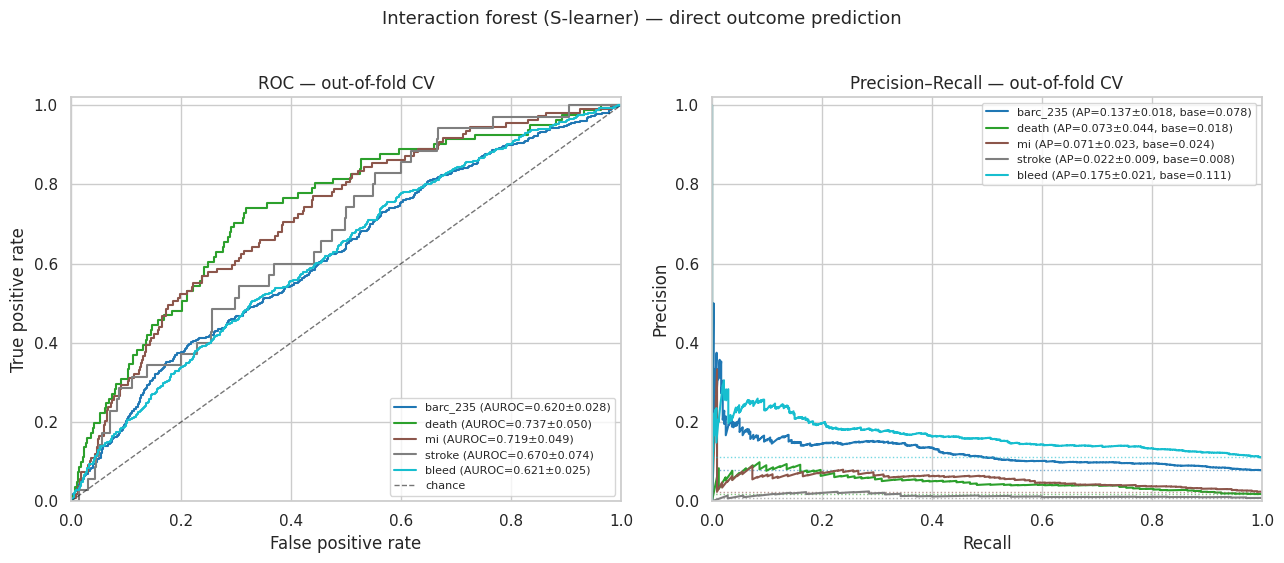

,positive_rate,AUROC,AUROC_std,AUPRC,AUPRC_std,AUPRC_lift
target,,,,,,
barc_235,0.078,0.620,0.028,0.137,0.018,1.742
death,0.018,0.737,0.050,0.073,0.044,4.147
mi,0.024,0.719,0.049,0.071,0.023,2.977
stroke,0.008,0.670,0.074,0.022,0.009,2.837
bleed,0.111,0.621,0.025,0.175,0.021,1.584


In [5]:
oof_summary = cv_roc_pr_curves(
    pipe, XT, y_df.values, cv=CV_FOLDS,
    columns=TARGET_LABELS,
    model_name='Interaction forest (S-learner) — direct outcome prediction',
)
display(oof_summary.round(3))

## Held-out confusion matrices

Tree ensembles rarely push the averaged positive-class probability above 0.5 for rare
events, so the default `.predict()` would label everyone negative. Instead we set a
per-endpoint threshold at the `(1 − event_rate)` quantile of **out-of-fold** training
probabilities (`event_rate_thresholds`) so the predicted-positive fraction tracks the true
event rate, then evaluate on a held-out split.

Per-endpoint thresholds: {'barc_235': np.float64(0.379), 'death': np.float64(0.327), 'mi': np.float64(0.329), 'stroke': np.float64(0.213), 'bleed': np.float64(0.416)}


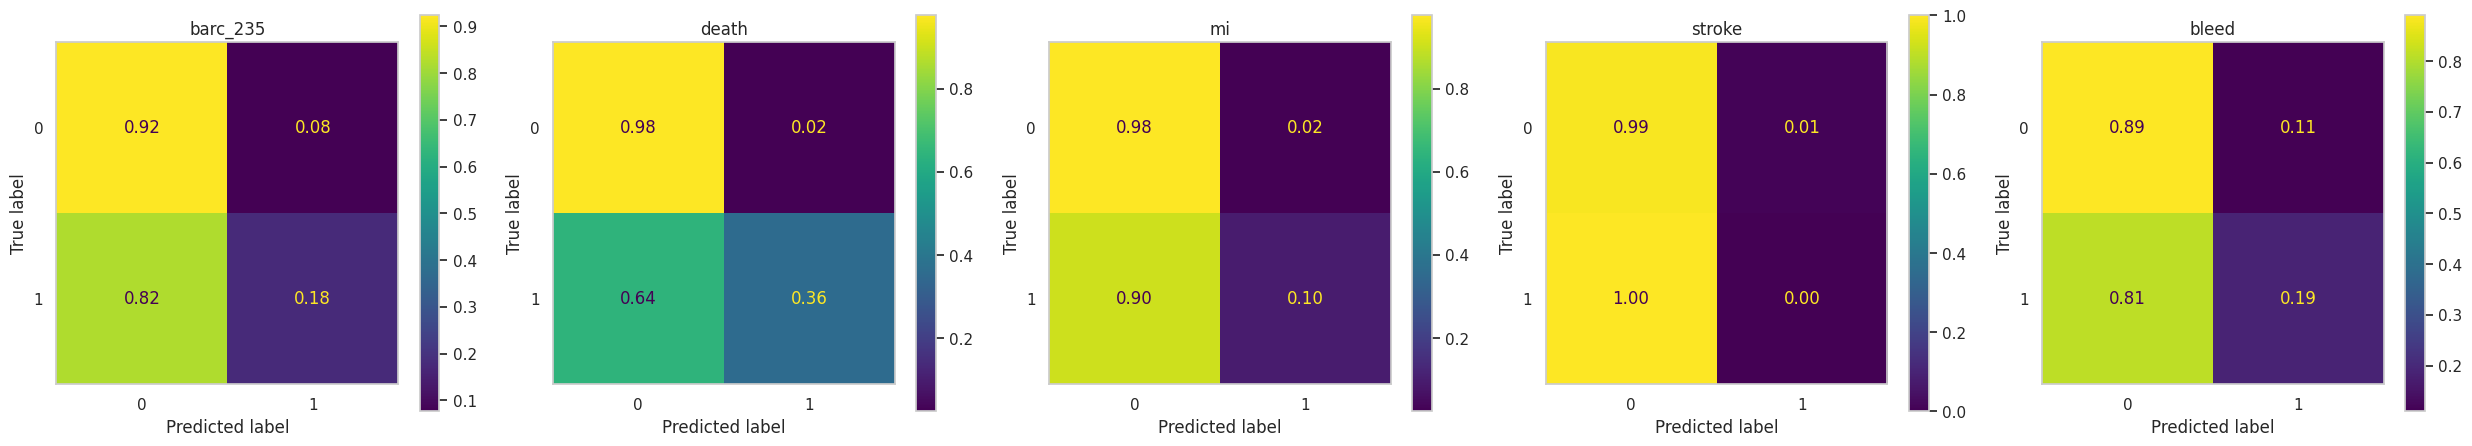

target         rate  PR-AUC  lift  ROC-AUC   P(1)   R(1)  F1(1)
---------------------------------------------------------------
barc_235      0.079   0.157  2.00    0.669   0.16   0.18   0.17
death         0.012   0.083  6.79    0.791   0.16   0.36   0.22
mi            0.027   0.059  2.18    0.659   0.10   0.10   0.10
stroke        0.007   0.020  2.81    0.630   0.00   0.00   0.00
bleed         0.111   0.175  1.58    0.645   0.18   0.19   0.18


In [6]:
XT_tr, XT_te, y_tr, y_te = train_test_split(
    XT, y_df, test_size=TEST_SIZE, random_state=42, stratify=y_df['cec_bleed_335d'],
)

pipe_split = make_interaction_forest(
    use_knn_imputer=USE_KNN_IMPUTER, knn_neighbors=KNN_NEIGHBORS, rf_params=RF_PARAMS,
).fit(XT_tr, y_tr.values.astype(int))

thresholds = event_rate_thresholds(pipe_split, XT_tr, y_tr.values, cv=CV_FOLDS)
print('Per-endpoint thresholds:', dict(zip(TARGET_LABELS, thresholds.round(3))))

# Score the held-out patients once; threshold-free metrics use the probabilities,
# the confusion matrices use the event-rate-thresholded labels.
proba_te = predict_proba_matrix(pipe_split, XT_te)
y_pred = (proba_te >= thresholds).astype(int)

cm_path = os.path.join(SAVE_DIR, 'CONFUSION_MATRICES', 'interaction_forest_cm.png')
plot_confusion_matrices(
    y_te.set_axis(TARGET_LABELS, axis=1), y_pred,
    titles=TARGET_LABELS, normalize=True, save_path=cm_path,
)

# Per-endpoint held-out report (prints; threshold-free PR/ROC-AUC + P/R/F1 at threshold).
report_test_performance(y_te.values, proba_te, thresholds, columns=TARGET_LABELS)

## Effect modification — the `X * T` interaction block

Refit on the **full** cohort and read the forest importances back out, decomposed into the
main covariate block, the treatment column, and the `X*T` interaction block. A covariate
with large **interaction importance** is one the forest uses to *change the treatment
response* — a candidate effect modifier. (These are impurity importances: read them as a
ranking, not as calibrated effect sizes.)

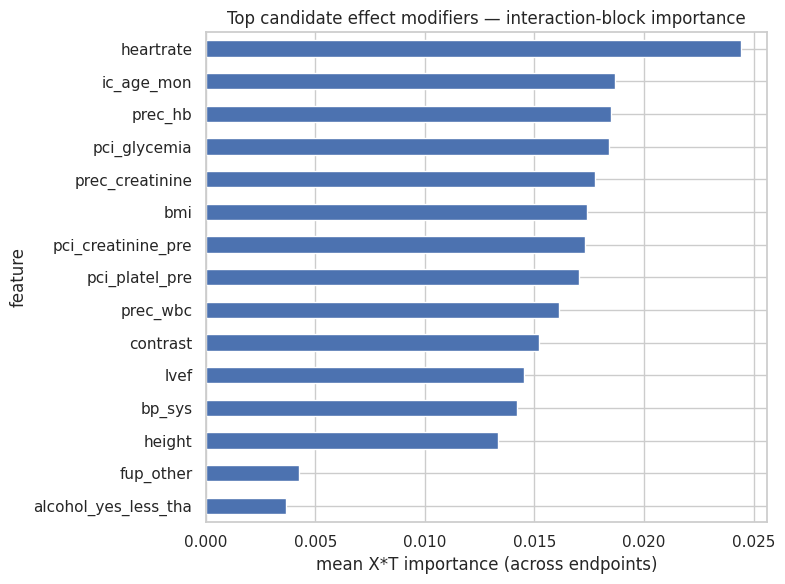

Treatment (T) main-effect importance per endpoint:
{'barc_235': 0.0029, 'death': 0.0026, 'mi': 0.0022, 'stroke': 0.003, 'bleed': 0.0047}


In [7]:
pipe.fit(XT, y_df.values.astype(int))

imp = interaction_importances(pipe, FEATURES, TARGET_LABELS)

# Average the effect-modification signal across endpoints and rank the covariates.
top_mod = (imp.groupby('feature')['interaction_importance'].mean()
              .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(8, 6))
top_mod[::-1].plot.barh(ax=ax, color='#4C72B0')
ax.set(xlabel='mean X*T importance (across endpoints)',
       title='Top candidate effect modifiers — interaction-block importance')
plt.tight_layout()
plt.show()

print('Treatment (T) main-effect importance per endpoint:')
print({k: round(v, 4) for k, v in imp.attrs['treatment_importance'].items()})

### Interaction importance per endpoint

Which covariates modify the treatment response for *each* outcome. Values are within-endpoint
shares of the `X*T` block (columns sum to 1), so they are comparable across endpoints; the
table shows the union of each endpoint's top modifiers.

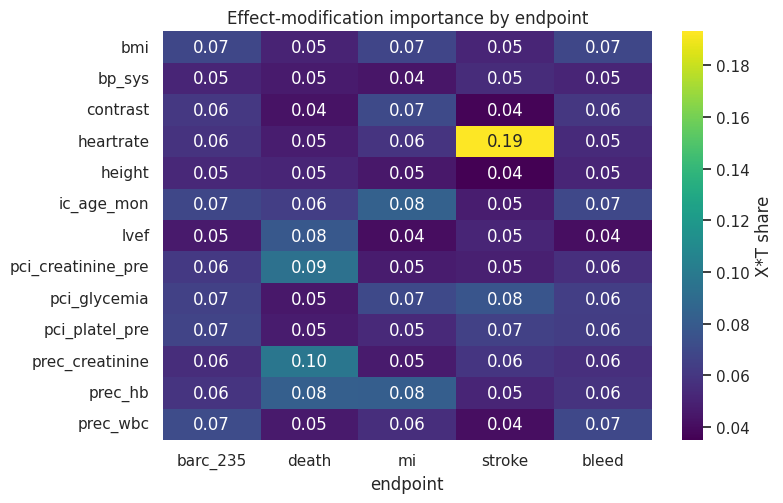

In [8]:
pivot = imp.pivot(index='feature', columns='target', values='interaction_importance')
pivot = pivot / pivot.sum(axis=0)   # within-endpoint share of the interaction block

top_feats = set()
for lab in TARGET_LABELS:
    top_feats.update(pivot[lab].sort_values(ascending=False).head(6).index)
heat = pivot.loc[sorted(top_feats), TARGET_LABELS]

fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(heat))))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': 'X*T share'}, ax=ax)
ax.set(title='Effect-modification importance by endpoint', xlabel='endpoint', ylabel='')
plt.tight_layout()
plt.show()

## Implied CATE from the S-learner — vs the causal forest

Force the treatment column to 1 and to 0 and difference the predicted probabilities:
`implied_cate = P(Y=1 | X, T=1) − P(Y=1 | X, T=0)`. All endpoints are *adverse*, and we
orient the axis with **abbreviated DAPT toward the positive**: a **positive** value means
abbreviated DAPT *lowers* that event's probability (prolonged raises it) — abbreviated is the
safer arm; a **negative** value means abbreviated DAPT raises the event. This is an in-sample,
non-doubly-robust readout of the forest's fitted response — the RandomForest overfits, so its
spread is an **upper** bound on genuine heterogeneity. Read it next to the causal forest, which
found CATE heterogeneity ≈ noise on this cohort.

S-learner implied CATE on outcome probability (adverse events: >0 = abbreviated DAPT safer)


,mean_CATE,std_CATE,pct_abbreviated_reduces_risk,pct_abbreviated_increases_risk
barc_235,0.051,0.087,78.576,21.424
death,-0.002,0.051,46.713,53.287
mi,-0.033,0.058,21.249,78.751
stroke,0.016,0.052,63.005,36.929
bleed,0.074,0.091,84.167,15.833


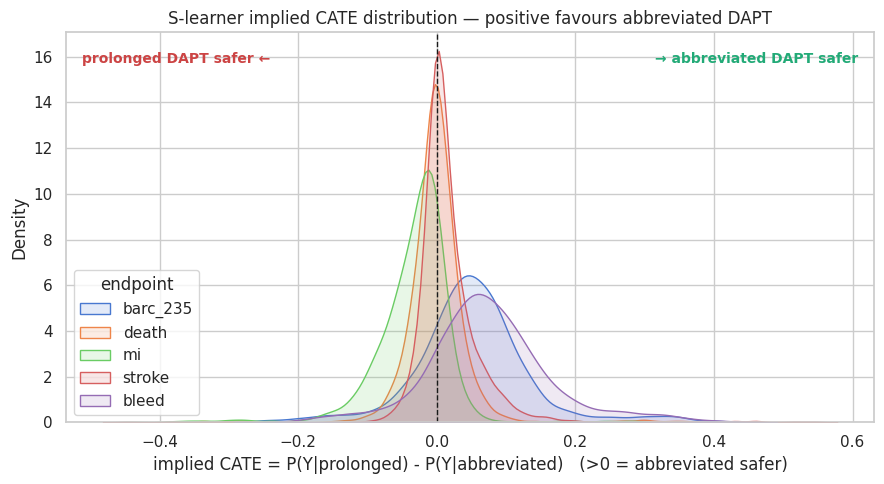

In [9]:
cate = pd.DataFrame(implied_cate(pipe, X_num.values), columns=TARGET_LABELS, index=X_num.index)

cate_summary = pd.DataFrame({
    'mean_CATE': cate.mean(),
    'std_CATE': cate.std(),
    'pct_abbreviated_reduces_risk': (cate > 0).mean() * 100,   # cate>0: fewer events under abbreviated
    'pct_abbreviated_increases_risk': (cate < 0).mean() * 100,
})
print('S-learner implied CATE on outcome probability (adverse events: >0 = abbreviated DAPT safer)')
display(cate_summary.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
for lab in TARGET_LABELS:
    sns.kdeplot(cate[lab], ax=ax, label=lab, fill=True, alpha=0.15)
ax.axvline(0, color='k', linestyle='--', linewidth=1)
# Orient the axis with abbreviated DAPT on the positive side.
ymax = ax.get_ylim()[1]
ax.text(0.98, 0.95, '→ abbreviated DAPT safer', transform=ax.transAxes, ha='right', va='top',
        color='#2a7', fontsize=10, fontweight='bold')
ax.text(0.02, 0.95, 'prolonged DAPT safer ←', transform=ax.transAxes, ha='left', va='top',
        color='#c44', fontsize=10, fontweight='bold')
ax.set(xlabel='implied CATE = P(Y|prolonged) - P(Y|abbreviated)   (>0 = abbreviated safer)',
       title='S-learner implied CATE distribution — positive favours abbreviated DAPT')
ax.legend(title='endpoint')
plt.tight_layout()
plt.show()

## Save the fitted pipeline

In [10]:
if SAVE_MODEL:
    os.makedirs(SAVE_DIR, exist_ok=True)
    path = os.path.join(SAVE_DIR, 'InteractionForest_multioutput.joblib')
    joblib.dump(pipe, path)
    print(f'Saved -> {os.path.relpath(path, os.getcwd())}')
else:
    print('SAVE_MODEL is False — skipping.')

Saved -> ../models/InteractionForest/InteractionForest_multioutput.joblib


## Takeaways

- The interaction forest is a **direct outcome predictor**: its discrimination is summarised
  by the out-of-fold ROC/PR table above, evaluated threshold-free and with rare-event-aware
  confusion matrices — comparable to the base classification models.
- The `X*T` block turns effect modification into a **readable importance ranking**: the
  top covariates are the ones the forest leans on to change the treatment response.
- The **implied CATE** is a second, model-different look at heterogeneity, oriented with
  **abbreviated DAPT on the positive side**. Because it is in-sample and non-doubly-robust it
  *over*-states dispersion, so if it is already modest it reinforces — rather than contradicts —
  the causal forest's homogeneous-effect conclusion. The clinically expected directions show up
  in the sign of `mean_CATE`: **positive for bleeding/BARC** (abbreviated DAPT is safer — fewer
  bleeds) and **negative for the ischaemic endpoints** (abbreviated DAPT slightly worse, i.e.
  prolonged protects against MI).